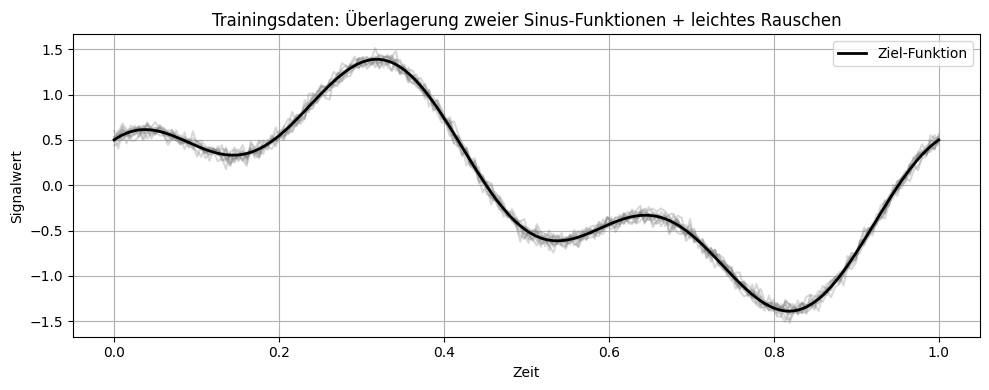

ValueError: Found input variables with inconsistent numbers of samples: [100, 500]

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

# --- Ziel-Funktion: feste, einfache Überlagerung ---
def base_function(x):
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(6 * np.pi * x)

# --- Trainingsdatensatz: viele Varianten der gleichen Funktion mit etwas Rauschen ---
def generate_dataset(n_samples=100, seq_len=200):
    x = np.linspace(0, 1, seq_len)
    X = []
    for _ in range(n_samples):
        signal = base_function(x)
        signal += 0.05 * np.random.randn(seq_len)  # leichtes Rauschen
        X.append(signal)
    X = np.array(X).astype(np.float32)
    return x, X

# --- Datensatz erzeugen ---
x, X = generate_dataset(n_samples=100)

# --- Visualisierung ---
plt.figure(figsize=(10, 4))

for i in range(10):  # Zeige 10 Beispiele
    plt.plot(x, X[i], color='gray', alpha=0.3)

# Zeige die Ziel-Funktion (ohne Rauschen)
plt.plot(x, base_function(x), color='black', linewidth=2, label='Ziel-Funktion')

plt.title("Trainingsdaten: Überlagerung zweier Sinus-Funktionen + leichtes Rauschen")
plt.xlabel("Zeit")
plt.ylabel("Signalwert")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

# --- 3. Einfaches 1D-CNN-Modell ---
net = nn.Sequential(
    nn.Conv1d(1, 4, kernel_size=11, padding=5),  # 4 Filter
    nn.ReLU(),
    nn.MaxPool1d(2),
    nn.Conv1d(4, 8, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(2),
    nn.Flatten(),
    nn.Linear(8 * 50, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

# --- 4. Training ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

for epoch in range(20):
    optimizer.zero_grad()
    outputs = net(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# --- 5. Testauswertung ---
net.eval()
with torch.no_grad():
    preds = net(X_test).argmax(dim=1)
    acc = accuracy_score(y_test, preds)
    print("Testgenauigkeit:", acc)

# --- 6. Visualisierung: Filter der ersten Conv1D-Schicht ---
filters = net[0].weight.data.cpu().numpy()  # Shape: (4, 1, 11)

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(filters[i, 0], label=f"Filter {i}")
plt.title("Gelernte 1D-Faltungskerne (1. Schicht)")
plt.xlabel("Position im Kernel")
plt.ylabel("Gewicht")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 7. Visualisierung: Aktivierungen eines Beispiels (Filterantworten) ---
with torch.no_grad():
    example_input = X_test[0:1]  # Shape: (1, 1, 200)
    activations = net[0](example_input)  # Erste Conv-Schicht → (1, 4, 200)
    activations = activations.squeeze().numpy()

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(activations[i], label=f"Antwort Filter {i}")
plt.title("Aktivierungen (Filterantworten) auf ein Beispielsignal")
plt.xlabel("Zeitposition")
plt.ylabel("Aktivierung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
